# **DATA VISUALISATIONS NOTEBOOK**

## Objectives

* The objective of the data visualisation stage is to visually explore patterns, relationships, and trends in the TMDB movie dataset. Visualisations make complex data easier to understand and help communicate insights to both technical and non-technical audiences.

## Inputs

* Cleaned dataset produced during ETL (tmdb_processed.csv)
* Python libraries: Pandas, Matplotlib, Seaborn, and Plotly
* Insights identified during the EDA stage

## Outputs

* Visual charts showing trends and relationships in the data
* Graphs illustrating distributions of key variables such as revenue, budget, and popularity
* Visual insights used to support hypothesis testing and storytelling

## Additional Comments

* Data visualisation helps simplify complex datasets by converting numerical information into visual formats. In this project, charts are used to identify patterns such as the relationship between budget and revenue, distribution of movie ratings, and trends in popularity.

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
from pathlib import Path

current_dir = Path.cwd()
current_dir

PosixPath('/Users/isaacola/Documents/vscode-project/Movie-Revenue-and-Success-Prediction/Movie-Revenue-and-Success-Prediction/Research')

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chdir() defines the new current directory

In [2]:
if (current_dir / "Dataset").exists() and (current_dir / "Research").exists():
    project_root = current_dir
elif (current_dir.parent / "Dataset").exists() and (current_dir.parent / "Research").exists():
    project_root = current_dir.parent
else:
    raise FileNotFoundError("Could not locate project root containing 'Dataset' and 'Research' folders.")

os.chdir(project_root)
print(f"Current directory set to: {Path.cwd()}")

Current directory set to: /Users/isaacola/Documents/vscode-project/Movie-Revenue-and-Success-Prediction/Movie-Revenue-and-Success-Prediction


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/isaacola/Documents/vscode-project/Movie-Revenue-and-Success-Prediction/Movie-Revenue-and-Success-Prediction'

# Section 1

### Visualisations

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [5]:
# Load processed dataset
data_path = Path("Dataset/Processed/tmdb_processed.csv")
if not data_path.exists():
    raise FileNotFoundError(f"Processed dataset not found at: {data_path.resolve()}")

df = pd.read_csv(data_path)
df.head()
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [6]:
# Set Visualization Style
sns.set(style="whitegrid")

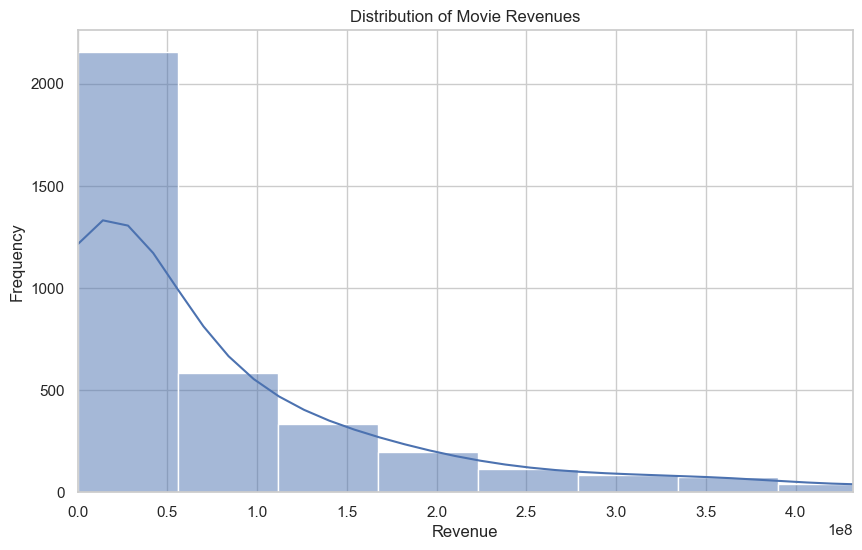

In [7]:
# Create distribution plot for revenue  
plt.figure(figsize=(10, 6))
sns.histplot(df['revenue'], bins=50, kde=True)
plt.title('Distribution of Movie Revenues')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.xlim(0, df['revenue'].quantile(0.95))
plt.show()

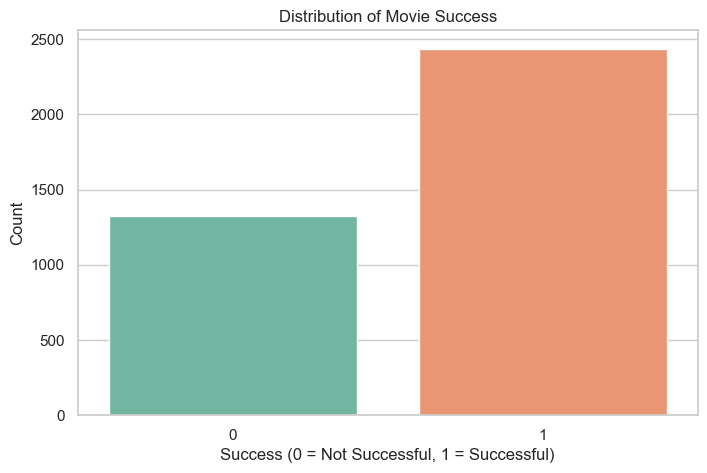

In [8]:
# Step 2: Visualize target variable distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="success", hue="success", palette="Set2", legend=False)
plt.title("Distribution of Movie Success")
plt.xlabel("Success (0 = Not Successful, 1 = Successful)")
plt.ylabel("Count")
plt.show()

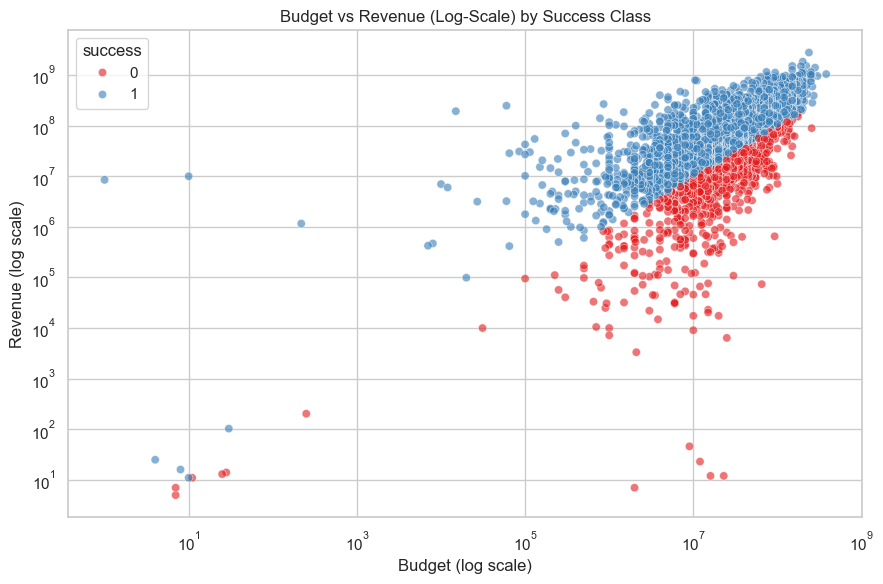

In [9]:
# Step 2b: Budget vs Revenue relationship by success class
plot_df = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="budget", y="revenue", hue="success", alpha=0.6, palette="Set1")
plt.xscale("log")
plt.yscale("log")
plt.title("Budget vs Revenue (Log-Scale) by Success Class")
plt.xlabel("Budget (log scale)")
plt.ylabel("Revenue (log scale)")
plt.tight_layout()
plt.show()

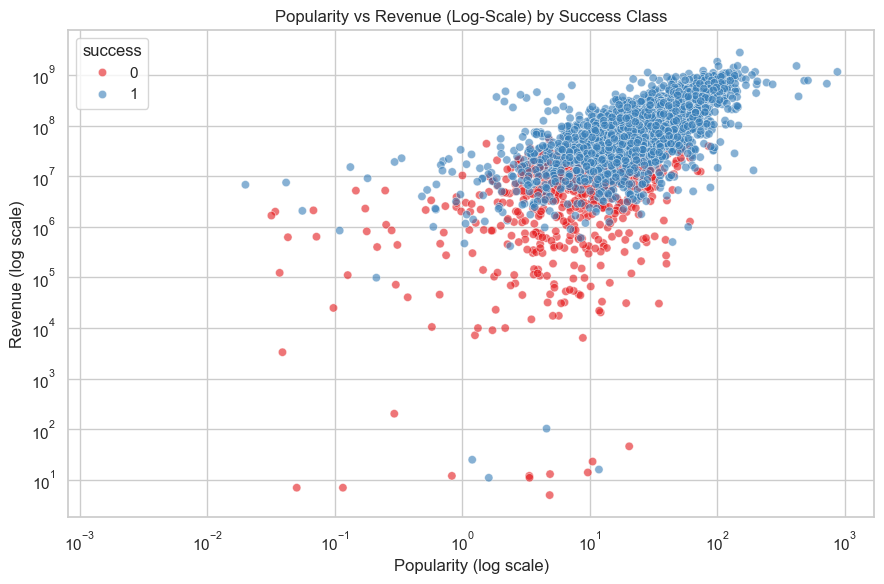

In [10]:
# Popularity vs Revenue
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="popularity", y="revenue", hue="success", alpha=0.6, palette="Set1")
plt.xscale("log")
plt.yscale("log")
plt.title("Popularity vs Revenue (Log-Scale) by Success Class")
plt.xlabel("Popularity (log scale)")
plt.ylabel("Revenue (log scale)")
plt.tight_layout()
plt.show()

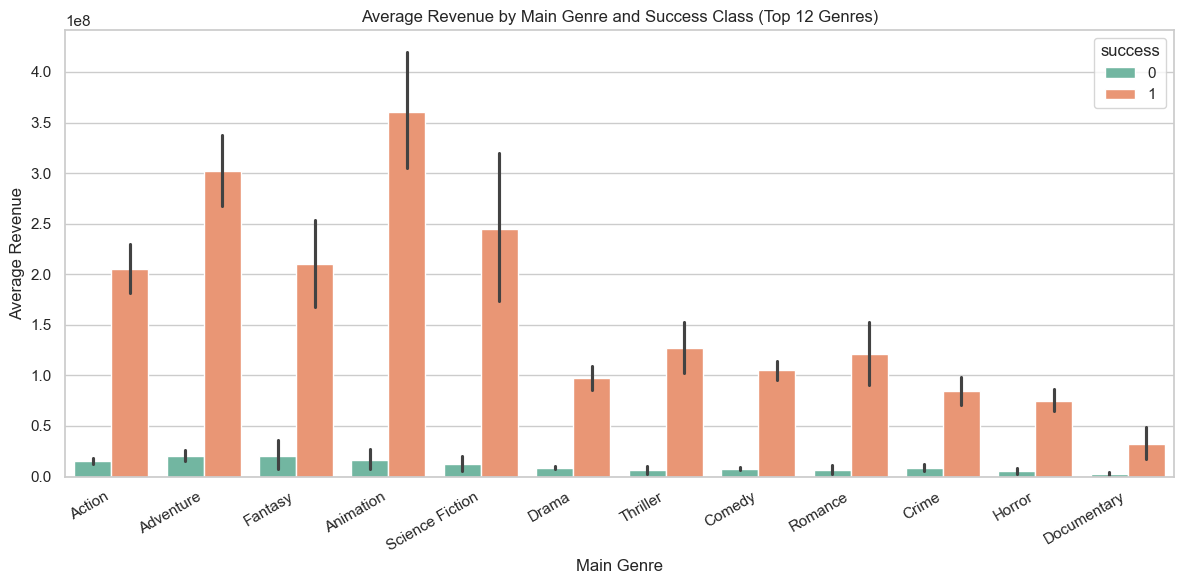

In [11]:
# Average Revenue by Main Genre
import ast

def extract_main_genre(genres_str):
    if not isinstance(genres_str, str) or not genres_str.strip():
        return "Unknown"
    try:
        genres_list = ast.literal_eval(genres_str)
        if isinstance(genres_list, list) and len(genres_list) > 0:
            first = genres_list[0]
            if isinstance(first, dict):
                return first.get("name", "Unknown")
    except (ValueError, SyntaxError):
        pass
    return "Unknown"

plot_df = df.copy()
plot_df["main_genre"] = plot_df["genres"].apply(extract_main_genre)
top_genres = plot_df["main_genre"].value_counts().head(12).index
plot_df = plot_df[plot_df["main_genre"].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="main_genre", y="revenue", hue="success", palette="Set2")
plt.title("Average Revenue by Main Genre and Success Class (Top 12 Genres)")
plt.xlabel("Main Genre")
plt.ylabel("Average Revenue")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

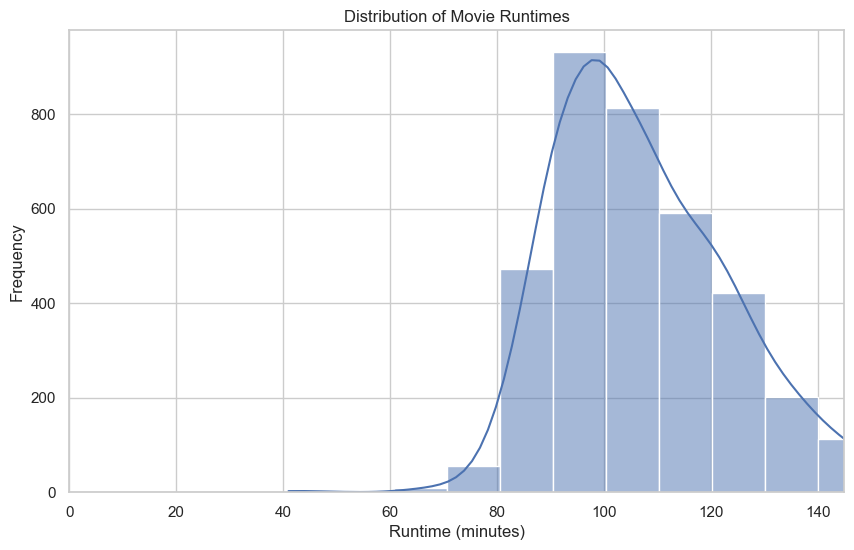

In [12]:
# Movie Runtime Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['runtime'], bins=30, kde=True)
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Frequency')
plt.xlim(0, df['runtime'].quantile(0.95))
plt.show()

---

# Section 2

## Advanced Visualisations

This section explores relationships and trends across key variables to support feature selection and modelling decisions.

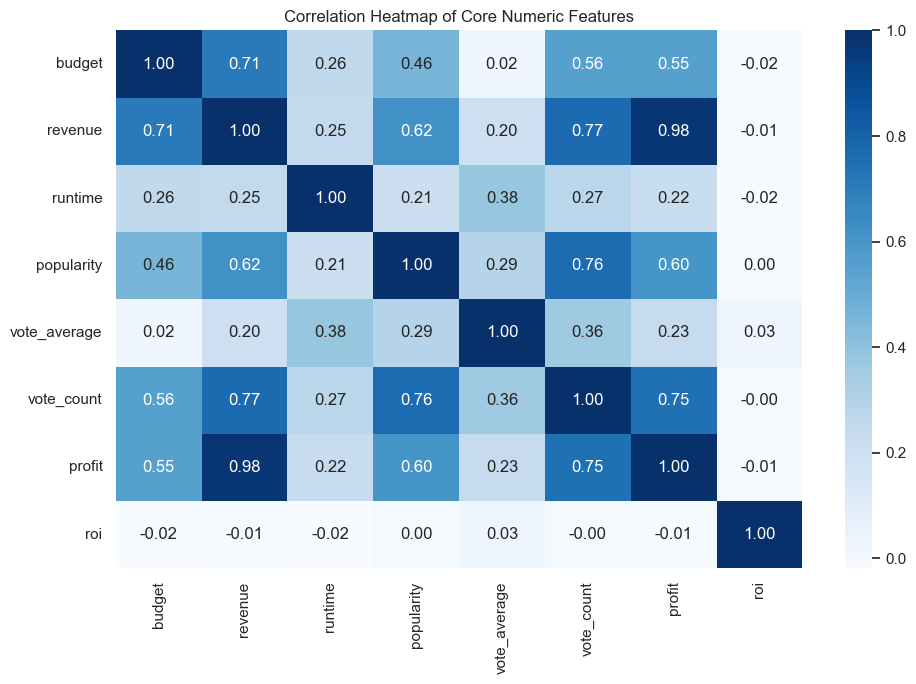

In [29]:
# Step 3: Correlation heatmap for core numeric features
numeric_features = ["budget", "revenue", "runtime", "popularity", "vote_average", "vote_count", "profit", "roi"]
available_numeric = [col for col in numeric_features if col in df.columns]

if available_numeric:
    corr = df[available_numeric].corr(numeric_only=True)
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
    plt.title("Correlation Heatmap of Core Numeric Features")
    plt.tight_layout()
    plt.show()
else:
    print("No expected numeric columns found for correlation analysis.")

In [30]:
# Save the correlation heatmap
from pathlib import Path

output_dir = Path("images")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
print("Saved: images/correlation_heatmap.png")

Saved: images/correlation_heatmap.png


<Figure size 640x480 with 0 Axes>

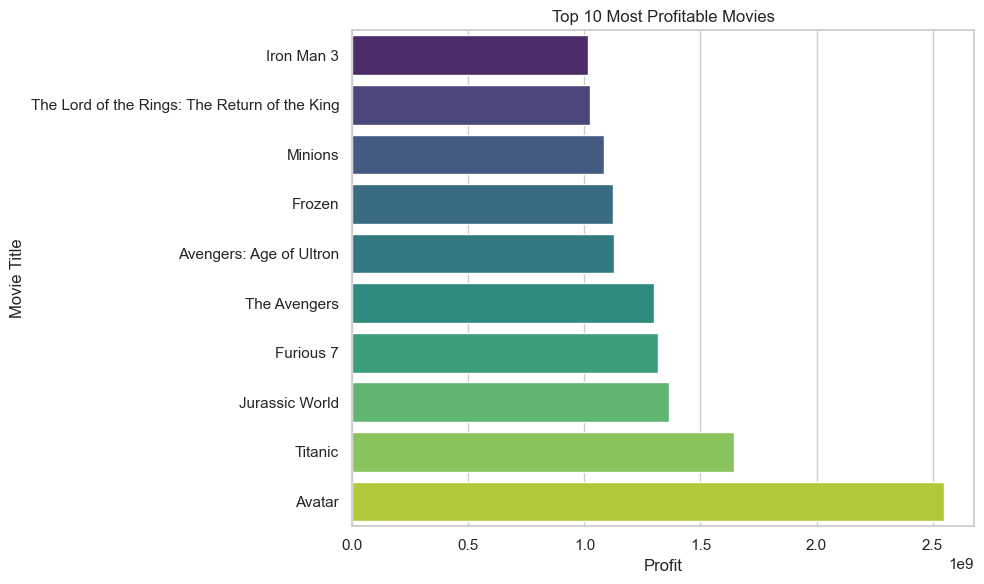

In [14]:
# Step 4: Top 10 movies by profit
if {"title", "profit"}.issubset(df.columns):
    top_profit = df.nlargest(10, "profit")[["title", "profit"]].sort_values("profit")
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_profit,
        x="profit",
        y="title",
        hue="title",
        palette="viridis",
        dodge=False,
        legend=False,
    )
    plt.title("Top 10 Most Profitable Movies")
    plt.xlabel("Profit")
    plt.ylabel("Movie Title")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns for top profit chart are missing.")

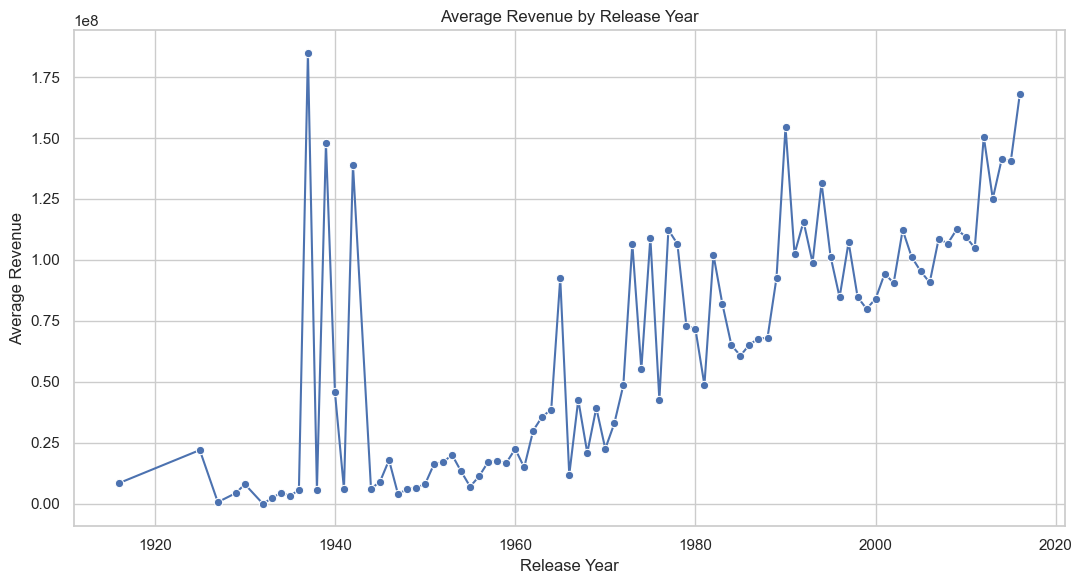

In [15]:
# Step 5: Revenue trend over release years
if {"release_year", "revenue"}.issubset(df.columns):
    trend = (
        df.dropna(subset=["release_year"])
          .groupby("release_year", as_index=False)["revenue"]
          .mean()
          .sort_values("release_year")
    )

    plt.figure(figsize=(11, 6))
    sns.lineplot(data=trend, x="release_year", y="revenue", marker="o")
    plt.title("Average Revenue by Release Year")
    plt.xlabel("Release Year")
    plt.ylabel("Average Revenue")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns for revenue trend chart are missing.")

---

# Section 3

### HYPOTHESIS
Hypothesis testing is used to determine whether relationships observed in the dataset are statistically significant or occurred by chance.

A significance level of 0.05 is used in this project.

If p-value < 0.05 → Reject the Null Hypothesis

If p-value ≥ 0.05 → Fail to Reject the Null Hypothesis

#### Hypothesis 1 — Budget vs Revenue
Hypothesis Question:
Is there a relationship between a movie’s budget and its revenue?

H₀ (Null Hypothesis): Movie budget has no effect on movie revenue.

H₁ (Alternative Hypothesis): Higher movie budgets lead to higher movie revenue.

**Test Used**

Pearson Correlation Test 

This test measures the strength and direction of the linear relationship between two continuous variables (Movie Budget and Movie Revenue)


In [24]:
# Pearson correlation test for budget and revenue
from scipy.stats import pearsonr

# Ensure dataset is available even if earlier cells were not run in this kernel.
if "df" not in globals():
    import pandas as pd
    from pathlib import Path
    data_path = Path("Dataset/Processed/tmdb_processed.csv")
    df = pd.read_csv(data_path)

h1_df = df[["budget", "revenue"]].dropna()
corr, p_value = pearsonr(h1_df["budget"], h1_df["revenue"] )

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.7097674381679372
P-value: 0.0


In [17]:
# Interpret results
if p_value < 0.05:
    print("Reject H0: There is a significant correlation between budget and revenue.")
else:
    print("Fail to reject H0: No significant correlation between budget and revenue.")

Reject H0: There is a significant correlation between budget and revenue.


#### Hypothesis 2 — Popularity vs Revenue
Hypothesis Question:

Is there a relationship between a movie’s popularity and its revenue?

H₀ (Null Hypothesis): Movie popularity does not influence revenue.

H₁ (Alternative Hypothesis): Higher popularity leads to higher revenue.

**Test Used**

Pearson Correlation Test 

In this analysis, the Pearson correlation test is used to determine whether there is a statistically significant relationship between movie popularity and movie revenue.

A positive correlation coefficient would indicate that movies with higher popularity tend to generate higher revenue, while a correlation close to zero would suggest little or no relationship between the two variables. 

In [25]:
# Additional correlation test for popularity and revenue
h2_df = df[["popularity", "revenue"]].dropna()
corr, p_value = pearsonr(h2_df["popularity"], h2_df["revenue"] )

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.6203535263351594
P-value: 0.0


In [19]:
# Interpret results
if p_value < 0.05:
    print("Reject H0: There is a significant correlation between popularity and revenue.")
else:
    print("Fail to reject H0: No significant correlation between popularity and revenue.")


Reject H0: There is a significant correlation between popularity and revenue.


#### Hypothesis 3 — Revenue Differences Across Genres

Hypothesis Question: Is there a significant difference in average movie revenue across different movie genres?

H₀ (Null Hypothesis): Average revenue is the same across all movie genres.

H₁ (Alternative Hypothesis):  At least one genre has a significantly different average revenue.

**Test Used**

ANOVA (Analysis of Variance)

This test is used to determine whether there are statistically significant differences between the means of three or more independent groups. In this case, ANOVA is applied to compare the average revenue across different movie genres to determine whether genre has an effect on revenue performance.

In [26]:
# ANOVA test for revenue across main genres
import ast
from scipy.stats import f_oneway
def extract_main_genre(genres_str):
    if not isinstance(genres_str, str) or not genres_str.strip():
        return "Unknown"
    try:
        genres_list = ast.literal_eval(genres_str)
        if isinstance(genres_list, list) and len(genres_list) > 0:
            first = genres_list[0]
            if isinstance(first, dict):
                return first.get("name", "Unknown")
    except (ValueError, SyntaxError):
        pass
    return "Unknown"
df["main_genre"] = df["genres"].apply(extract_main_genre)
top_genres = df["main_genre"].value_counts().head(10).index
anova_df = df[df["main_genre"].isin(top_genres)]
groups = [anova_df[anova_df["main_genre"] == genre]["revenue"].dropna() for genre in top_genres]
f_stat, p_anova = f_oneway(*groups)
print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_anova)

ANOVA F-statistic: 52.77837505257698
ANOVA p-value: 2.579980034902635e-90


In [21]:
# Interpret ANOVA results
if p_anova < 0.05:
    print("Reject H0: Average revenue differs significantly across main genres.")
else:
    print("Fail to reject H0: No significant difference in average revenue across main genres.")

Reject H0: Average revenue differs significantly across main genres.


#### Hypothesis 4 — Success vs Budget Quartile

Hypothesis Question: Is movie success associated with the budget quartile of a movie?

H₀ (Null Hypothesis): Movie success is independent of budget quartile.
H₁ (Alternative Hypothesis): Movie success is associated with budget quartile.

**Test Used**

Chi-Square Test of Independence

This test is used to determine whether there is a significant association between two categorical variables. In this analysis, the Chi-square test examines whether movie success (e.g., successful vs not successful) is related to the budget quartile category of the movie.

In [27]:
# Chi-square test for success and budget quartile
from scipy import stats

chi_df = df[["budget", "success"]].dropna().copy()
chi_df = chi_df[chi_df["budget"] > 0]
chi_df["budget_group"] = pd.qcut(chi_df["budget"], q=4, duplicates="drop")
cont_table = pd.crosstab(chi_df["budget_group"], chi_df["success"])
chi2, p_chi, _, _ = stats.chi2_contingency(cont_table)

print("Chi-square statistic:", chi2)
print("Chi-square p-value:", p_chi)

Chi-square statistic: 121.50821341216349
Chi-square p-value: 3.652587857303167e-26


In [23]:
# Interpret chi-square results
if p_chi < 0.05:
    print("Reject H0: Movie success is associated with budget quartile.")
else:
    print("Fail to reject H0: Movie success is independent of budget quartile.")

Reject H0: Movie success is associated with budget quartile.


## Conclusions

- The target variable is moderately imbalanced, with 2,438 successful movies and 1,324 unsuccessful movies.
- Revenue, profit, popularity, and vote_count display strong right-skewness, indicating that a relatively small number of blockbuster films account for a large share of totals.
- Correlation analysis indicates strong positive relationships among key financial variables, particularly revenue with profit (0.98) and budget with revenue (0.71).
- The log-scale budget-versus-revenue scatterplot shows successful films clustered at higher revenue levels across comparable budget ranges, supporting the predictive relevance of financial features.
- The top-profit ranking indicates that profitability is highly concentrated in a limited set of titles (for example, Avatar and Titanic), consistent with heavy-tail behavior.
- At alpha = 0.05, all inferential tests in Section 3 reject their tested null hypotheses: budget is associated with revenue, popularity is associated with revenue, average revenue differs across major genres, and success is associated with budget quartile.